# Pricing d'Options : De Monte-Carlo à Black-Scholes

Ce notebook présente l'implémentation de deux méthodes classiques en finance quantitative pour le pricing d'options européennes :

Le modèle analytique de **Black-Scholes**.

La méthode numérique de simulation de **Monte-Carlo**.

L'étude de la **convergence** de Monte-Carlo vers Black-Scholes.

*Auteur : Mehdi Belhamiti*

In [29]:
%pip install scipy

In [30]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

## 1. Modèle de Black-Scholes

Le modèle de Black-Scholes fournit une formule fermée pour évaluer le prix théorique d'une option européenne. Il suppose que le prix du sous-jacent suit un Mouvement Brownien Géométrique.

Les formules analytiques pour un Call ($C$) et un Put ($P$) sont :
$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$
$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

Avec :
$$d_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$$
$$d_2 = d_1 - \sigma \sqrt{T}$$

*Où $N(x)$ est la fonction de répartition de la loi normale centrée réduite.*

In [31]:
def black_scholes(S0, K, T, sigma, r):
    """
    calcule le prix d'un Call et d'un Put européens selon le modèle de Black-Scholes

    Paramètres :
    S0    : float - Prix actuel du sous-jacent
    K     : float - Prix d'exercice (Strike)
    T     : float - Maturité de l'option en années
    sigma : float - Volatilité (écart-type)
    r     : float - Taux sans risque

    Retourne :
    (float, float) - Prix du Call et Prix du Put
    """
    d1 = (np.log(S0 / K) + (r + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    C = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    P = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

    print("--- Résultat Black-Scholes ---")
    print(f"Prix du Call : {C:.3f} €")
    print(f"Prix du Put  : {P:.3f} €\n")

    return np.round(C, 3), np.round(P, 3)

In [32]:
# Paramètres initiaux utilisés pour les deux modèles
S0 = 15     # Cours actuel
K = 21      # Strike
T = 1       # Maturité 1 an
sigma = 0.36 # Volatilité 36%
r = 0.04    # Taux sans risque 4%

bs_call, bs_put = black_scholes(S0, K, T, sigma, r)

--- Résultat Black-Scholes ---
Prix du Call : 0.715 €
Prix du Put  : 5.892 €



## 2. Simulation de Monte-Carlo

La méthode de Monte-Carlo repose sur la simulation de nombreuses trajectoires possibles de l'actif sous-jacent jusqu'à la maturité. Selon la loi des grands nombres, le prix de l'option est approché par l'espérance mathématique empirique des payoffs actualisés.

La dynamique du sous-jacent en temps discret est simulée par :
$$S_t = S_{t-1} \exp\left((r - \frac{\sigma^2}{2})dt + \sigma \sqrt{dt} Z\right)$$

*Où $Z \sim \mathcal{N}(0,1)$ est une variable aléatoire normale et $dt$ le pas de temps.*

In [33]:
def monte_carlo_pricing(S0, K, T, sigma, r, M=1000, N=252):
    """
    simule les trajectoires de l'actif sous-jacent avec Monte-Carlo et évalue le prix de l'option

    Paramètres :
    M : int - Nombre de trajectoires simulées
    N : int - Nombre de pas de temps (ex : 252 jours de trading)
    """
    dt = T / N
    S = np.zeros((N + 1, M))
    S[0] = S0

    # Genération de trajectoire par simulation de la loi normale
    for t in range(1, N + 1):
        Z = np.random.normal(0, 1, M)
        S[t] = S[t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)

    #calcul des payoffs finaux à maturité (T)
    S_T = S[-1]
    payoffs_c = np.maximum(S_T - K, 0)
    payoffs_p = np.maximum(K - S_T, 0)

    # actualisation des moyennes des payoffs
    prix_mc_c = np.mean(payoffs_c) * np.exp(-r * T)
    prix_mc_p = np.mean(payoffs_p) * np.exp(-r * T)

    print(f"--- Résultat Monte-Carlo ({M} trajectoires) ---")
    print(f"Prix du Call : {prix_mc_c:.3f} €")
    print(f"Prix du Put  : {prix_mc_p:.3f} €")

    # Visualisation des trajectoires
    plt.figure(figsize=(10, 6))
    # Affichage limité à 100 trajectoires max
    plt.plot(S[:, :min(100, M)], alpha=0.5)
    plt.axhline(y=K, color='black', linestyle='--', linewidth=2, label='Strike (K)')
    plt.title(f"Simulation de Monte-Carlo : {M} trajectoires (max 100 affichées)")
    plt.xlabel("Pas de temps (jours)")
    plt.ylabel("Prix de l'action ($S_t$)")
    plt.legend()
    plt.show()

    return np.round(prix_mc_c, 3), np.round(prix_mc_p, 3)

--- Résultat Monte-Carlo (1000 trajectoires) ---
Prix du Call : 0.637 €
Prix du Put  : 6.044 €


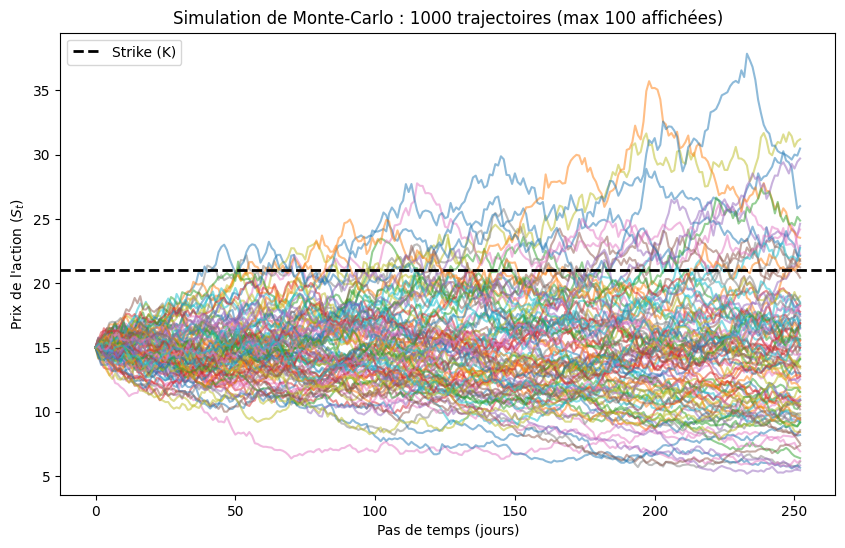

In [34]:
# on exécute avec 1000 trajectoires
mc_call, mc_put = monte_carlo_pricing(S0, K, T, sigma, r, M=1000, N=252)

## 3. Analyse de la convergence

Théoriquement, avec la Loi des Grands Nombres, le prix issu de Monte-Carlo tend vers le prix théorique (Black-Scholes) lorsque le nombre de simulations $M$ augmente. Par
le Théorème Central Limite, on sait également que l'erreur décroît à un taux proportionnel à $1/\sqrt{M}$.

In [38]:
def calculer_convergence(S0, K, T, r, sigma, M_max):
    """
    Fonction utilitaire pour calculer la convergence des prix de Monte-Carlo.
    Calcule les prix par moyenne cumulée pour optimiser le temps d'execution
    ici, nous nous concentrons sur le pricing d'un Call
    """
    # --- Prix Black-Scholes
    d1 = (np.log(S0 / K) + (r + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    prix_bs = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

    # --- Monte-Carlo

    # on simule M_max valeurs de la normale
    Z = np.random.normal(0, 1, M_max)
    #Calcul direct du sous-jacent à maturité T
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    # Payoffs du Call
    payoffs = np.maximum(S_T - K, 0) * np.exp(-r * T)

    # calcul de la moyenne cumulée pour chaque sous-ensemble
    M = np.arange(1, M_max + 1)
    prix_mc = np.cumsum(payoffs) / M

    # Erreur absolue
    erreurs = np.abs(prix_mc - prix_bs)

    return M, prix_mc, erreurs, prix_bs

def plot_convergence(S0, K, T, r, sigma, M_max=50000):
    # appel de la fonction de calcul
    M, prix_mc, erreurs, prix_bs = calculer_convergence(S0, K, T, r, sigma, M_max)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Graph 1 : prix estimé vs vrai prix
    ax1.plot(M, prix_mc, label="Estimateur Monte-Carlo (Call)", color='blue', linewidth=1)
    ax1.axhline(y=prix_bs, color='red', linestyle='--', linewidth=2, label=f"Prix Black-Scholes ({round(prix_bs, 2)}€)")
    ax1.set_ylabel("Prix de l'Option (€)")
    ax1.set_title(f"Convergence de Monte-Carlo vers Black-Scholes (M={M_max})")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Graph 2 : l'erreur
    ax2.plot(M, erreurs, color='orange', linewidth=1, label="Erreur Absolue")
    ax2.set_xlabel("Nombre de simulations (M)")
    ax2.set_ylabel("Erreur (|MC - BS|)")
    ax2.set_title("Diminution de l'erreur d'estimation")
    ax2.grid(True, alpha=0.3)

    #Tracer la ligne théorique de l'erreur en 1/sqrt(M)
    y_theorique = 10 / np.sqrt(M)
    ax2.plot(M, y_theorique, color='green', linestyle=':', label=r"Théorie $\to 1/\sqrt{M}$")
    ax2.legend()

    plt.tight_layout()
    plt.show()

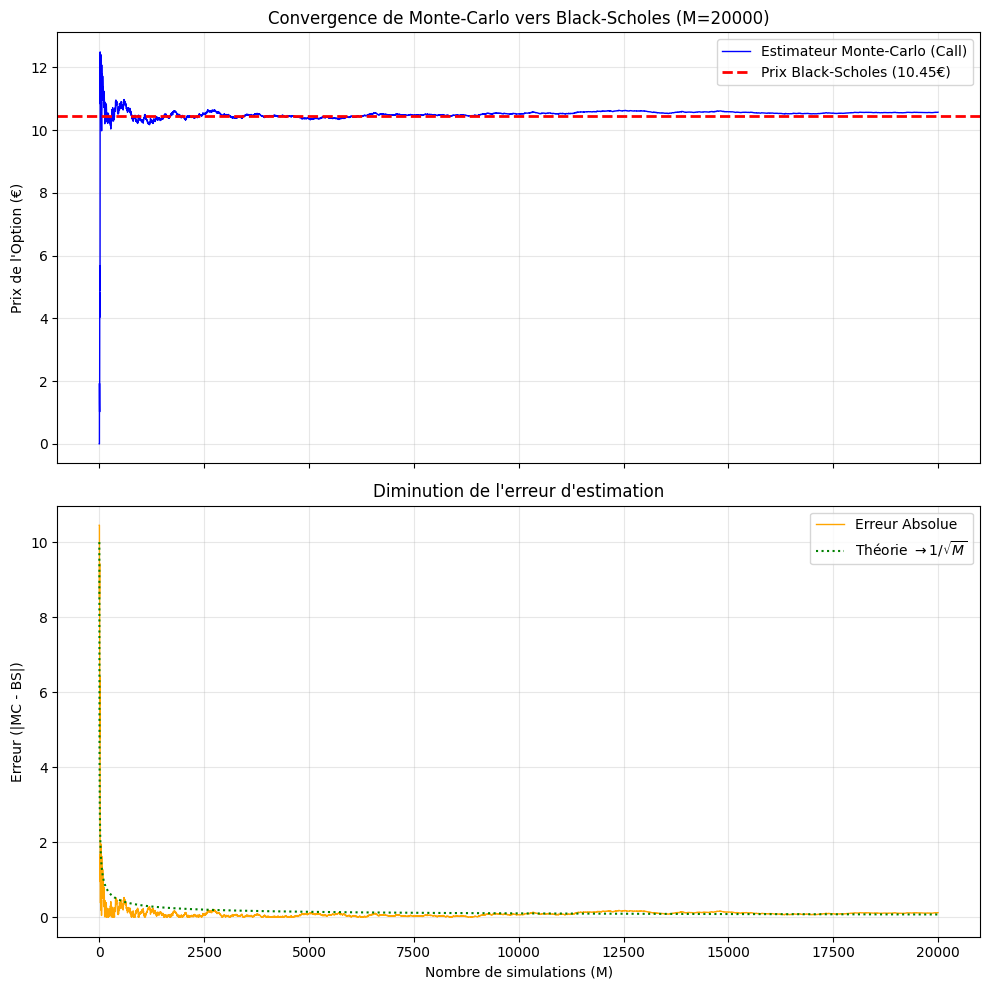

In [39]:
# paramètres initiaux
S0 = 100
K = 100
T = 1
sigma = 0.2
r = 0.05

plot_convergence(S0, K, T, r, sigma, M_max=20000)

## Conclusion

Les graphiques ci-dessus démontrent de manière très claire le comportement de l'estimateur de Monte-Carlo :

**Graphique 1** : Plus $M$ augmente, plus la valeur simulée converge et se stabilise sur le trait rouge (la valeur théorique de Black-Scholes)

**Graphique 2** : L'erreur absolue diminue bien à une vitesse en $O(1/\sqrt{M})$, comme le prédit la théorie

Bien qu'elle soit numériquement plus lourde, la méthode de Monte-Carlo est particulièrement puissante car elle offre la flexibilité nécessaire pour évaluer des produits dérivés complexes où les formules analytiques n'existent pas